In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data=pd.read_csv("polynomial_data.csv")
x=data["x_train"].values
y=data["y_train"].values

x_train = x.reshape(-1,1)
y = y.reshape(-1,1)

m = x.shape[0]
alpha = 0.01

print(x_train.shape, y.shape)

(140, 1) (140, 1)


In [2]:
#DEGREE
d = 17
x = np.zeros((m, d))

#POLYNOMIAL FEATURES
for i in range(1, d+1):
    x[:, i-1] = x_train[:, 0] ** i

#NORMALIZATION
mean = np.mean(x, axis=0)
std = np.std(x, axis=0)
x = (x-mean) / std

(140, 1)


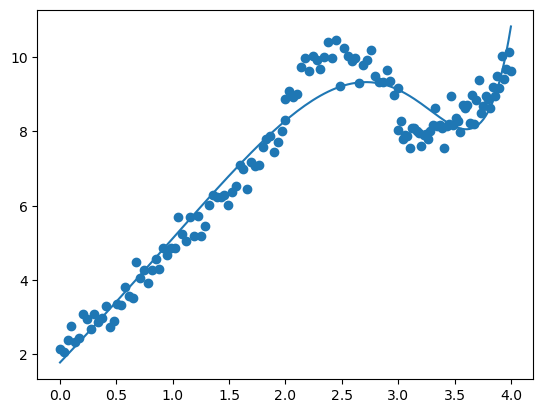

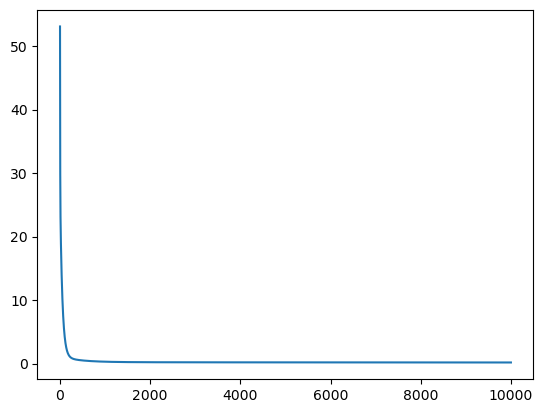

In [3]:
w = np.random.rand(1,d)
b = np.array([[0]])

cost_history = []

for _ in range(10000):
    y_ = (w @ x.T + b).T
    
    cost = np.sum((y_ - y) ** 2) / (2 * m)
    cost_history.append(cost)
    djdw = ((x.T @ (y_ - y)) / m).T
    djdb = np.mean((y_ - y))
    
    w = w - alpha * djdw
    b = b - alpha * djdb
    
#PREDICTION
y_ = (w @ x.T + b).T

print(y_.shape)
plt.scatter(x_train,y)
plt.plot(x_train,y_)
plt.show()
plt.plot(cost_history)
plt.show()